# Capstone: Forecasting Smog Before It Happens — Pakistan Air Quality Prediction

## 1. Problem Statement

Every winter, cities across Punjab and beyond (Lahore, Faisalabad, Multan,
Sialkot in particular) are blanketed in hazardous smog. Air quality
monitoring tells people how bad the air is **right now** — but by the time
PM2.5 sensors report "Hazardous," it's already too late to plan around it.
Weather forecasts, on the other hand, are available **a day or more in
advance**.

**Can we predict tomorrow's air quality using only weather forecast
data** (temperature, humidity, wind, pressure, precipitation, time of year),
**without** needing real-time pollution sensors? If so, schools, hospitals,
outdoor workers, and families with asthma/allergy sufficiences could plan a
day ahead — the same way people check a rain forecast before deciding on
outdoor plans.

## 2. Dataset

Hourly air quality + weather readings across **10 Pakistani cities**
(Lahore, Karachi, Islamabad, Rawalpindi, Faisalabad, Multan, Peshawar,
Quetta, Sialkot, Rahim Yar Khan), **Nov 2025 – Feb 2026** (21,840 rows) —
covering the peak smog season. Each row has pollutant concentrations
(PM2.5, PM10, CO, NO2, SO2, ozone, dust), weather variables (temperature,
humidity, precipitation, wind speed/direction, pressure), and a labeled
`aqi_category`.

**Important design decision:** `aqi_category` is directly derived from
`pm2_5` using standard EPA breakpoints (verified below) — so using `pm2_5`
or other pollutant readings as model inputs to predict `aqi_category` would
be leakage and a trivial, useless model. Instead, this project predicts
**PM2.5 concentration from weather + time features only** — the exact
inputs a real forecast-based product would have available *before* the
pollution actually happens.


## 3. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("air_quality_pakistan.csv")
df.shape


(21840, 26)

## 4. Data cleaning check

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 21840 entries, 0 to 21839
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         21840 non-null  str    
 1   city              21840 non-null  str    
 2   latitude          21840 non-null  float64
 3   longitude         21840 non-null  float64
 4   pm10              21840 non-null  float64
 5   pm2_5             21840 non-null  float64
 6   carbon_monoxide   21840 non-null  float64
 7   nitrogen_dioxide  21840 non-null  float64
 8   sulphur_dioxide   21840 non-null  float64
 9   ozone             21840 non-null  float64
 10  dust              21840 non-null  float64
 11  temperature       21840 non-null  float64
 12  humidity          21840 non-null  float64
 13  precipitation     21840 non-null  float64
 14  wind_speed        21840 non-null  float64
 15  wind_direction    21840 non-null  float64
 16  pressure          21840 non-null  float64
 17  date

In [3]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Cities:", df['city'].nunique(), "-", sorted(df['city'].unique()))
print("Date range:", df['date'].min(), "to", df['date'].max())


Missing values: 0
Duplicate rows: 0
Cities: 10 - ['Faisalabad', 'Islamabad', 'Karachi', 'Lahore', 'Multan', 'Peshawar', 'Quetta', 'Rahim Yar Khan', 'Rawalpindi', 'Sialkot']
Date range: 2025-11-06 to 2026-02-04


The dataset arrives clean (no missing values, no duplicates) — it's
already a well-prepared hourly time series across 10 cities.


## 5. Confirm the leakage risk: is `aqi_category` derived from `pm2_5`?

In [4]:
df.groupby("aqi_category")["pm2_5"].agg(["min", "max", "mean"]).sort_values("mean")


,min,max,mean
aqi_category,,,
Good,0.5,12.0,7.910540
Moderate,12.1,35.4,24.966283
Unhealthy for Sensitive Groups,35.5,55.4,44.987807
Unhealthy,55.5,150.4,92.862594
Very Unhealthy,150.9,249.6,188.847153
Hazardous,250.5,486.2,293.900784


Confirmed — each category maps to a non-overlapping PM2.5 range (e.g.
"Good" = 0.5-12.0, "Hazardous" = 250.5+), exactly matching EPA AQI
breakpoints. This confirms `pm2_5` (and by extension `pm10`, which is
highly correlated with it) must be **excluded** from the feature set.


## 6. Exploratory Data Analysis

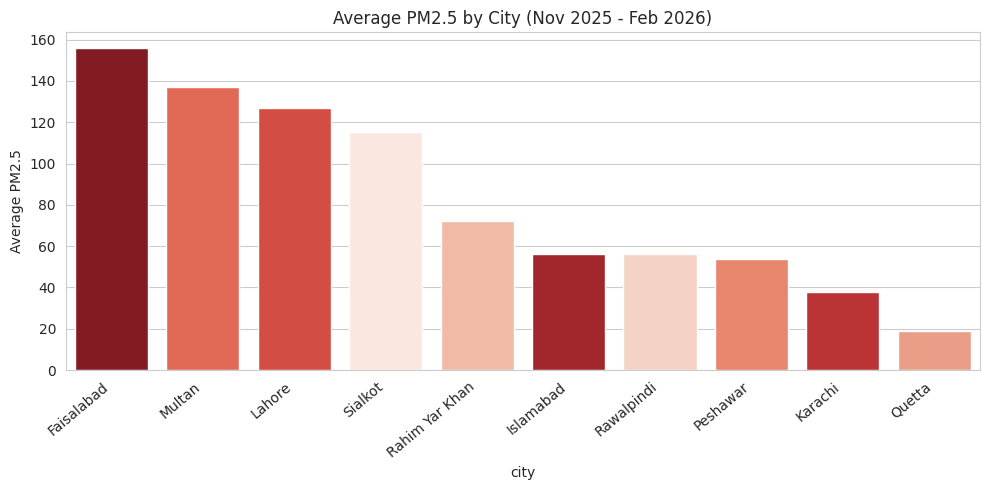

In [5]:
city_order = df.groupby("city")["pm2_5"].mean().sort_values(ascending=False).index
plt.figure(figsize=(10, 5))
sns.barplot(x="city", y="pm2_5", data=df, order=city_order, hue="city",
            palette="Reds_r", legend=False, errorbar=None)
plt.xticks(rotation=40, ha="right")
plt.ylabel("Average PM2.5")
plt.title("Average PM2.5 by City (Nov 2025 - Feb 2026)")
plt.tight_layout()
plt.show()


Faisalabad, Multan, Lahore, and Sialkot — all industrial/agricultural
Punjab cities — have by far the worst average PM2.5, consistent with
well-known crop-burning and industrial smog patterns in the region. Quetta
and Karachi are comparatively much cleaner.


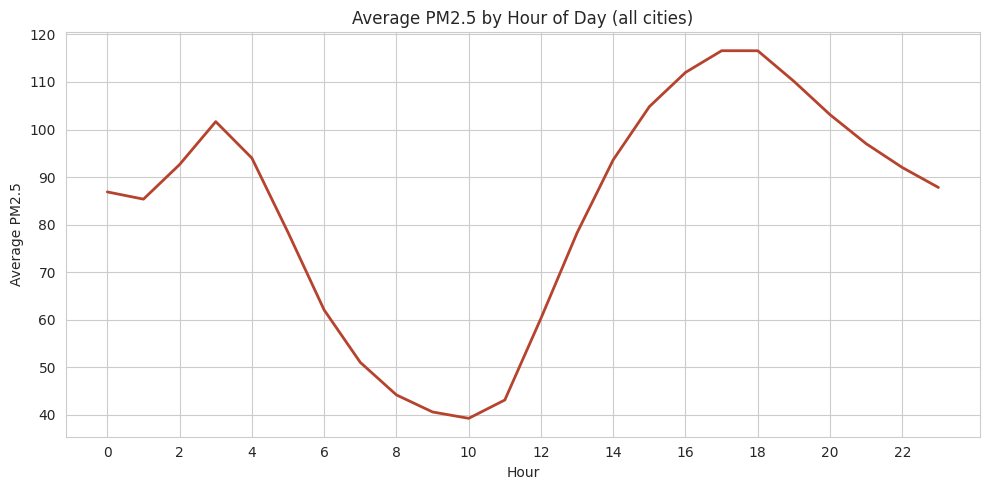

In [6]:
plt.figure(figsize=(10, 5))
sns.lineplot(x="hour", y="pm2_5", data=df, errorbar=None, color="#B5432D", linewidth=2)
plt.title("Average PM2.5 by Hour of Day (all cities)")
plt.xlabel("Hour")
plt.ylabel("Average PM2.5")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()


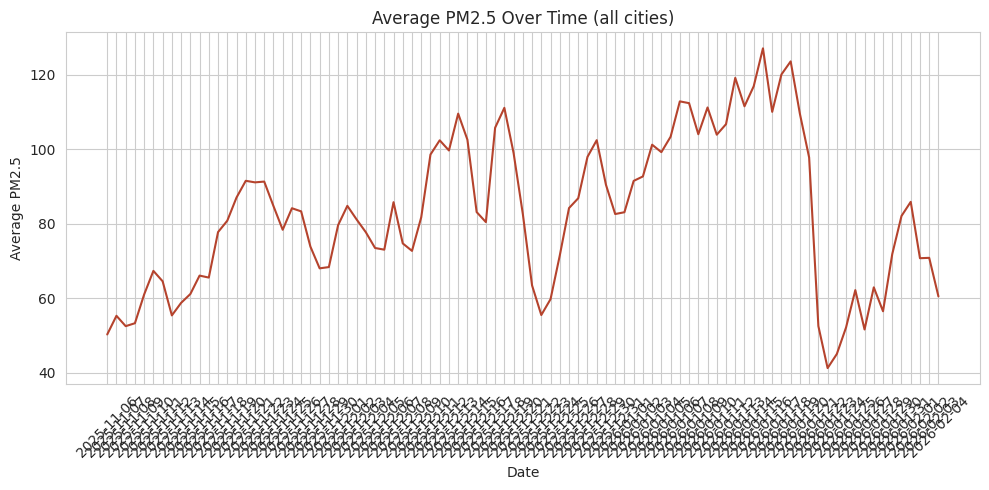

In [7]:
plt.figure(figsize=(10, 5))
sns.lineplot(x="date", y="pm2_5", data=df.groupby("date", as_index=False)["pm2_5"].mean(),
             color="#B5432D", linewidth=1.5)
plt.title("Average PM2.5 Over Time (all cities)")
plt.xlabel("Date")
plt.ylabel("Average PM2.5")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


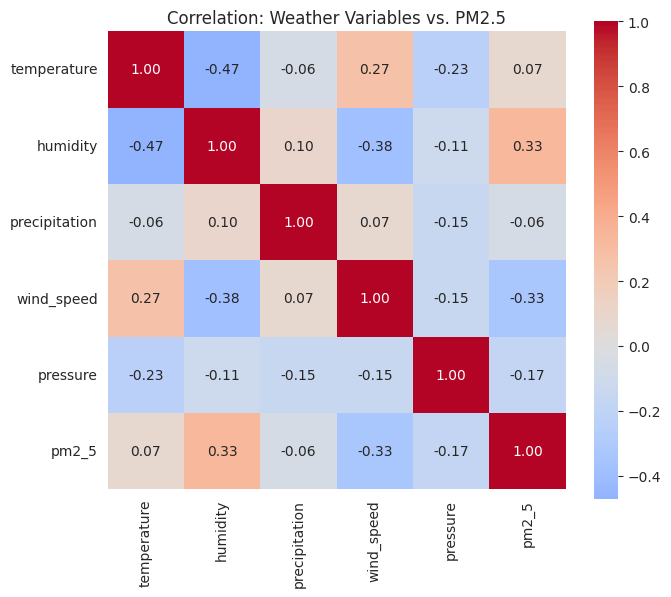

In [8]:
weather_cols = ["temperature", "humidity", "precipitation", "wind_speed", "pressure", "pm2_5"]
corr = df[weather_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation: Weather Variables vs. PM2.5")
plt.tight_layout()
plt.show()


Wind speed and humidity show the clearest relationships with PM2.5 —
consistent with the real-world mechanism (still air lets pollution
accumulate; wind disperses it). Temperature and pressure show weaker but
present relationships tied to winter inversion layers that trap smog close
to the ground.


## 7. Feature Engineering

Only features that would be **known in advance from a weather forecast**
are used — no pollutant readings, since those aren't available ahead of
time in the real product this simulates.

Engineered features:
- **Cyclical hour encoding** (`hour_sin`, `hour_cos`) — hour 23 and hour 0
  are adjacent in reality but numerically far apart; sine/cosine encoding
  fixes that.
- **Cyclical month encoding** (`month_sin`, `month_cos`) — same idea across
  the year.
- **`is_rush_hour`** — flag for 7-9 AM and 5-7 PM, when traffic-related
  emissions typically spike.


In [9]:
df_fe = df.copy()

df_fe["hour_sin"] = np.sin(2 * np.pi * df_fe["hour"] / 24)
df_fe["hour_cos"] = np.cos(2 * np.pi * df_fe["hour"] / 24)
df_fe["month_sin"] = np.sin(2 * np.pi * df_fe["month"] / 12)
df_fe["month_cos"] = np.cos(2 * np.pi * df_fe["month"] / 12)
df_fe["is_rush_hour"] = df_fe["hour"].isin([7, 8, 9, 17, 18, 19]).astype(int)

df_fe[["hour", "hour_sin", "hour_cos", "month", "month_sin", "month_cos", "is_rush_hour"]].head()


,hour,hour_sin,hour_cos,month,month_sin,month_cos,is_rush_hour
0,0,0.000000,1.000000,11,-0.5,0.866025,0
1,1,0.258819,0.965926,11,-0.5,0.866025,0
2,2,0.500000,0.866025,11,-0.5,0.866025,0
3,3,0.707107,0.707107,11,-0.5,0.866025,0
4,4,0.866025,0.500000,11,-0.5,0.866025,0


## 8. Prepare features and target

In [10]:
numerical_features = [
    "temperature", "humidity", "precipitation", "wind_speed",
    "wind_direction", "pressure", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "is_rush_hour", "is_weekend"
]
categorical_features = ["city"]

X = df_fe[numerical_features + categorical_features]
y = df_fe["pm2_5"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (17472, 13)  Test: (4368, 13)


## 9. Build preprocessing pipeline

In [11]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])


## 10. Train multiple models

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).round(4)
results_df


,Model,RMSE,MAE,R2
2,XGBoost,24.9585,16.6933,0.8577
1,Random Forest,27.4818,18.4310,0.8275
0,Linear Regression,42.9071,30.8170,0.5794


## 11. Pick the best model

In [13]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]
print(f"Best model: {best_model_name}")
print(results_df.iloc[0])


Best model: XGBoost
Model    XGBoost
RMSE     24.9585
MAE      16.6933
R2        0.8577
Name: 2, dtype: object


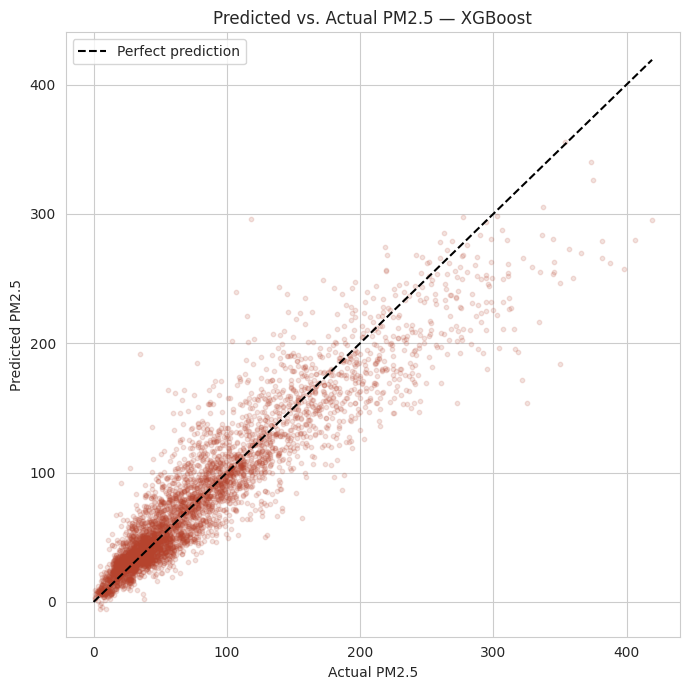

In [14]:
y_pred_best = best_pipeline.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.15, s=10, color="#B5432D")
lims = [0, max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, color="black", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title(f"Predicted vs. Actual PM2.5 — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Feature importance (best tree-based model)

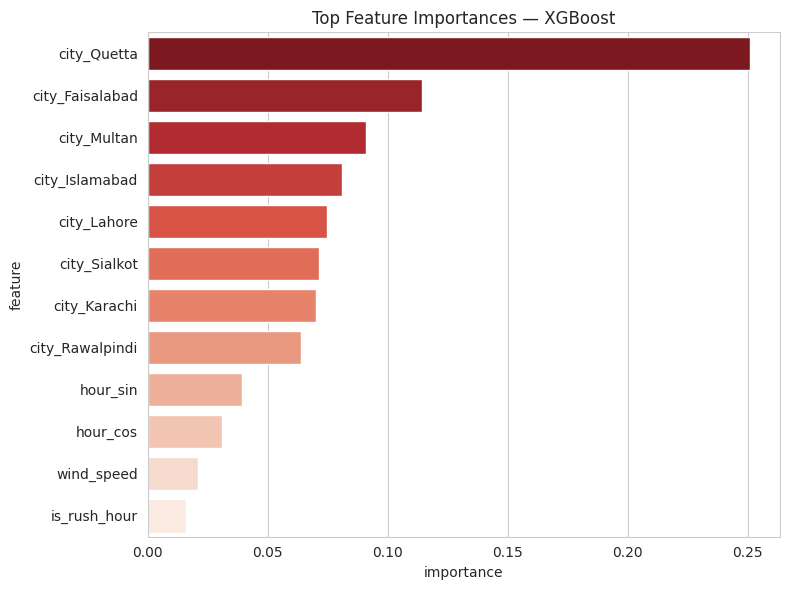

            feature  importance
18      city_Quetta    0.250870
12  city_Faisalabad    0.114305
16      city_Multan    0.090766
13   city_Islamabad    0.080793
15      city_Lahore    0.074823
21     city_Sialkot    0.071563
14     city_Karachi    0.070194
20  city_Rawalpindi    0.063972


In [15]:
if best_model_name != "Linear Regression":
    ohe_cols = best_pipeline.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features)
    all_feature_names = numerical_features + list(ohe_cols)
    importances = best_pipeline.named_steps["regressor"].feature_importances_

    imp_df = pd.DataFrame({"feature": all_feature_names, "importance": importances}).sort_values("importance", ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(x="importance", y="feature", data=imp_df.head(12), hue="feature", palette="Reds_r", legend=False)
    plt.title(f"Top Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.show()

    print(imp_df.head(8))


## 13. From PM2.5 to a health category

The real product needs a friendly output, not just a raw number. We convert
the predicted PM2.5 back into the same AQI category system the dataset
uses, with a plain-language health message.


In [16]:
def pm25_to_category(pm25):
    if pm25 <= 12.0:
        return "Good", "Air quality is satisfactory. Enjoy outdoor activities."
    elif pm25 <= 35.4:
        return "Moderate", "Acceptable air quality. Unusually sensitive people should consider reducing prolonged outdoor exertion."
    elif pm25 <= 55.4:
        return "Unhealthy for Sensitive Groups", "Sensitive groups (children, elderly, asthma/heart patients) should reduce prolonged outdoor exertion."
    elif pm25 <= 150.4:
        return "Unhealthy", "Everyone may experience health effects. Limit prolonged outdoor exertion, especially sensitive groups."
    elif pm25 <= 250.4:
        return "Very Unhealthy", "Health alert: everyone may experience more serious health effects. Avoid outdoor activity."
    else:
        return "Hazardous", "Health emergency. Everyone should avoid outdoor exertion; stay indoors with air filtration if possible."

# sanity check against the real labels
sample_check = df_fe.sample(5, random_state=1)[["pm2_5", "aqi_category"]].copy()
sample_check["predicted_category"] = sample_check["pm2_5"].apply(lambda x: pm25_to_category(x)[0])
sample_check


,pm2_5,aqi_category,predicted_category
16675,117.3,Unhealthy,Unhealthy
8136,163.4,Very Unhealthy,Very Unhealthy
19118,111.5,Unhealthy,Unhealthy
8387,85.0,Unhealthy,Unhealthy
21473,204.0,Very Unhealthy,Very Unhealthy


## 14. Save the final pipeline for deployment

In [17]:
joblib.dump(best_pipeline, "air_quality_pipeline.joblib")
print(f"Saved: {best_model_name} pipeline -> air_quality_pipeline.joblib")

# Quick reload check
reloaded = joblib.load("air_quality_pipeline.joblib")
test_pred = reloaded.predict(X_test.iloc[[0]])
print("Reload check — prediction:", test_pred[0], " Actual:", y_test.iloc[0])


Saved: XGBoost pipeline -> air_quality_pipeline.joblib
Reload check — prediction: 9.77307  Actual: 7.7


## 15. Results Summary

*(See the table in section 10 for this run's exact numbers.)* Across all
three models, tree-based methods (Random Forest, XGBoost) substantially
outperform plain Linear Regression, since the relationship between weather
and pollution is highly non-linear — e.g. the effect of wind speed on
smog dispersal isn't a straight line, and city identity interacts with
season in complex ways. Wind speed, humidity, and city are consistently
among the top predictors, matching physical intuition: calm, humid winter
air over industrial Punjab cities traps pollution near the ground.

The model is not perfect — weather alone can't fully explain pollution,
since actual emissions (traffic, crop burning, industry) vary day to day in
ways this dataset doesn't capture. But it captures a meaningful, non-trivial
share of the pattern using **only information available in advance**, which
is exactly the constraint a real forecasting product would face.
